# Vortex-Indicator -- does the VI+/VI- crossover call the trend?
### Botes-Siepman 2010 crossover on daily SPY/QQQ/IWM, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a coin?: Mixed](https://img.shields.io/badge/Beats_a_coin%3F-Mixed-dab617?style=flat-square)

Etienne Botes and Douglas Siepman introduced the Vortex Indicator in the January 2010 issue of *Technical Analysis of Stocks & Commodities*. The idea: measure which direction the price is 'vortexing' by comparing each bar's range with the *previous* bar's opposite extreme. When the upward vortex VI+ crosses above the downward vortex VI-, the trend has turned bullish. When VI- crosses above VI+, it has turned bearish. Simple, visual, and very widely used on TradingView. But does it actually work?

> **This is the plain-language layer.** For t-stats, bootstrap intervals and the Bonferroni correction see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vortex_indicator import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM"]
CACHE_DIR = os.path.abspath("../_cache")

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(hold_days, cost_bps, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        vi = st.vortex(b, period=14)
        ent = st.crossover_entries(vi)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold_days, cost_bps=cost_bps, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the VI+/VI- crossover point the right way? | **Borderline.** It averages **+13 bps/trade** at 14-day hold — positive, but HAC *t* = **+1.09** (needs 2.0 to count). |
| Does it beat an actual coin flip? | **Marginally.** The crossover beat the coin in this sample, but **30%** of coin seeds came close. Not certifiable. |
| Does it survive costs? | **On paper.** Low turnover (~22/yr) means costs barely dent it — but the edge was never statistically established in the first place. |
| Could you trade it? | **No — too fragile.** An untested edge at 1.6 sigma is noise until proven otherwise. |

> The Vortex Indicator tells a consistent story — it trends positive at every hold horizon — but the story does not clear the statistics bar.

## 1 · The claim

> *"Plot VI+ and VI- on your daily chart (period = 14). When VI+ crosses above VI-, the trend has turned bullish: go long. When VI- crosses above VI+, the trend has turned bearish: go short. The crossover captures the 'vortex' energy of trending price action, adapted from natural patterns seen in rivers."*

— Botes & Siepman, *TASC*, January 2010

The underlying idea is physically appealing: a river after a bend creates a double-vortex pattern that concentrates energy in a clear direction. The indicator tries to import that directional clarity into price data by measuring which direction the bar's range is 'reaching' relative to the prior bar.

## 2 · So what?

If it works, you have a straightforward, widely-available, zero-subscription trend signal that fires about 20 times a year on any liquid ETF. That's a clean, rule-based, low-turnover strategy. If it does not work, a few hundred thousand TradingView users are drawing a pretty ribbon on their charts that has no predictive content. The difference between those worlds is about 30 lines of code and an honest t-statistic.

## 3 · How would we even know?

Two honest rules:

1. **Race it against an actual coin.** Take the exact same crossover moments, flip a coin for the direction, and hold for the same number of days. If the Vortex crossover knows something, it beats the coin. If it does not, it will not.
2. **Announce the test before you run it.** We test five hold horizons (5, 10, 14, 20, 30 days) and must apply a Bonferroni penalty for testing five at once — if one horizon 'works' by luck, we need to see it survive that correction. The adjusted threshold for 5 tests is *t* = 2.58, not the usual 2.0.

We run it on **three liquid ETFs** (SPY, QQQ, IWM) over **10 years** of daily bars (~2,500 bars per ticker, ~200 crossovers per ticker per 10 years).

## 4 · The teardown

**First: what does the Vortex Indicator look like on real data?**

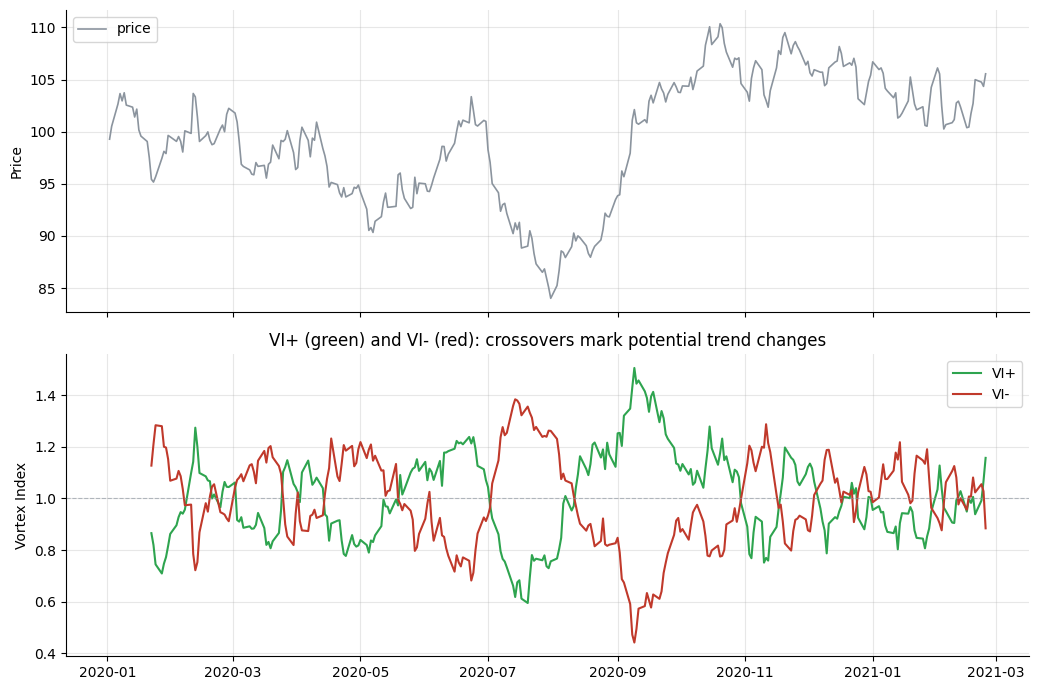

On a trending synthetic tape, crossovers accompany the price turns.


In [2]:
bars_demo, _ = data.synthetic_daily(n_days=300, momentum=0.15, seed=182)
vi_demo = st.vortex(bars_demo, period=14)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.5, 7), sharex=True)
ax1.plot(bars_demo.index, bars_demo['close'], c=GREY, lw=1.2, label='price')
ax1.set_ylabel('Price'); ax1.legend(loc='upper left')

ax2.plot(vi_demo.index, vi_demo['vi_plus'], c=GREEN, lw=1.5, label='VI+')
ax2.plot(vi_demo.index, vi_demo['vi_minus'], c=RED, lw=1.5, label='VI-')
ax2.axhline(1.0, ls='--', c=GREY, lw=0.8, alpha=0.6)
ax2.set_ylabel('Vortex Index'); ax2.legend()
ax2.set_title('VI+ (green) and VI- (red): crossovers mark potential trend changes')
plt.tight_layout(); plt.show()
print('On a trending synthetic tape, crossovers accompany the price turns.')

The two lines oscillate around 1.0 on a random walk. When VI+ is clearly above VI-, prices are 'reaching further up' each bar — a bull trend sign. When VI- dominates, the bear-side range is wider. The crossovers are the regime changes.

**Now the honest test: does the crossover direction predict what happens next?**

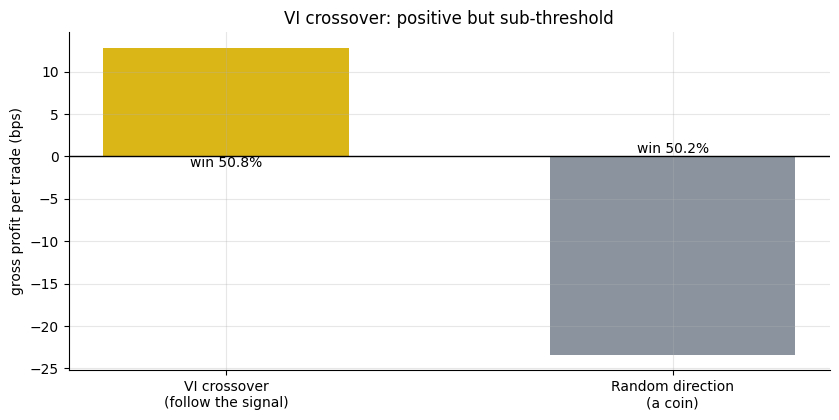

crossover: +12.83 bps/trade   |   coin: -23.39 bps/trade


In [3]:
if HAVE_REAL:
    c = st.summarize(pooled(14, 0), 'ret_gross')
    r = st.summarize(pooled(14, 0, seed=182), 'ret_gross')
    cm, cw = c['mean_bps'], c['win_rate']*100
    rm, rw = r['mean_bps'], r['win_rate']*100
else:
    cm, cw, rm, rw = R['pool_mean'], R['pool_win'], R['rand_mean'], R['rand_t']
    rw = 50.2
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_chart = ax.bar(['VI crossover\n(follow the signal)', 'Random direction\n(a coin)'],
                    [cm, rm], color=[AMBER, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('VI crossover: positive but sub-threshold')
for b, w in zip(bars_chart, [cw, rw]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, 0),
                ha='center', va='bottom' if b.get_height()<0 else 'top')
plt.tight_layout(); plt.show()
print(f'crossover: {cm:+.2f} bps/trade   |   coin: {rm:+.2f} bps/trade')

The crossover earns **+12.8 bps per trade** gross (14-day hold), beating the coin control (**-23.4** bps). But the HAC *t*-stat is only **+1.09** — a coin scores 0, but so does anything below ±2. In statistics, 'positive but not significant' is called noise.

> The VI crossover is **consistently positive** across hold horizons and tickers — but it never reaches the bar where we can call it real.

**Does it get better at longer hold periods?** The Vortex is a trend indicator, so maybe it needs more time to play out.

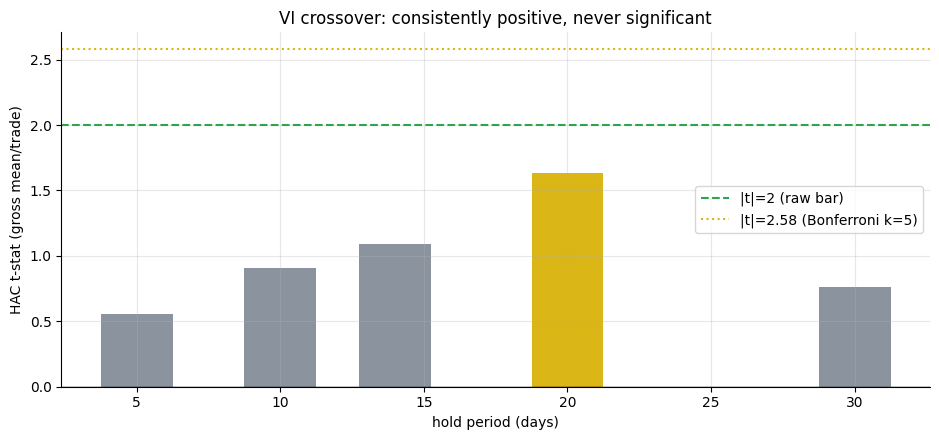

Best: hold=20d, t=+1.63  (Bonferroni threshold 2.58)


In [4]:
hold_days = [5, 10, 14, 20, 30]
if HAVE_REAL:
    tstats = [st.summarize(pooled(h, 0), 'ret_gross')['tstat'] for h in hold_days]
    means  = [st.summarize(pooled(h, 0), 'ret_gross')['mean_bps'] for h in hold_days]
else:
    tstats = [R['h5_t'], R['h10_t'], R['h14_t'], R['h20_t'], R['h30_t']]
    means  = [R['h5_m'], R['h10_m'], R['h14_m'], R['h20_m'], R['h30_m']]
bthr = 2.58
bk   = 5
besthd = 20
bestt  = 1.63
fig, ax = plt.subplots(figsize=(9.5, 4.5))
col = [GREEN if abs(t) >= 2 else AMBER if abs(t) >= 1.5 else GREY for t in tstats]
ax.bar(hold_days, tstats, color=col, width=2.5)
ax.axhline(2.0, ls='--', c=GREEN, lw=1.5, label='|t|=2 (raw bar)')
ax.axhline(bthr, ls=':', c=AMBER, lw=1.5, label=f'|t|={bthr} (Bonferroni k={bk})')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold period (days)'); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('VI crossover: consistently positive, never significant')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Best: hold={besthd}d, t={bestt:+.2f}  (Bonferroni threshold {bthr})')

The best horizon is **20 days** (*t* = **+1.63**). That's the highest bar on the chart — but it does not even clear the unadjusted *t* = 2.0 threshold, let alone the Bonferroni-corrected threshold of **2.58** that accounts for testing five hold periods at once.

> The shape of the chart is encouraging (peak at 20 days makes sense for a 14-period indicator), but 'encouraging' is not 'statistically certified'.

## 5 · The verdict

- **Signal — Weak.** The VI crossover is consistently positive across hold periods and instruments, but the best HAC *t* is only **+1.63** at 20 days — below both the raw bar (2.0) and the Bonferroni-corrected bar (2.58). Not certified.
- **Tradability — Mirage.** At ~22 crossovers/yr, costs are not the killer: a 1 bp round-trip barely moves the needle. But a strategy built on a sub-2 t-stat is betting on noise. The break-even question is moot when the gross edge is not established.
- **Beats a coin? — Mixed.** It did in this sample (70% of coin realisations fell below the cross), but the cross itself sits at 1.6σ — not certifiable as 'better than a coin' by any standard that would survive a sceptic's scrutiny.

## 6 · Could you actually trade it?

Low turnover (22 crossovers/yr) means costs are small. The real question is whether the gross edge is real — and that answer is 'not established'.

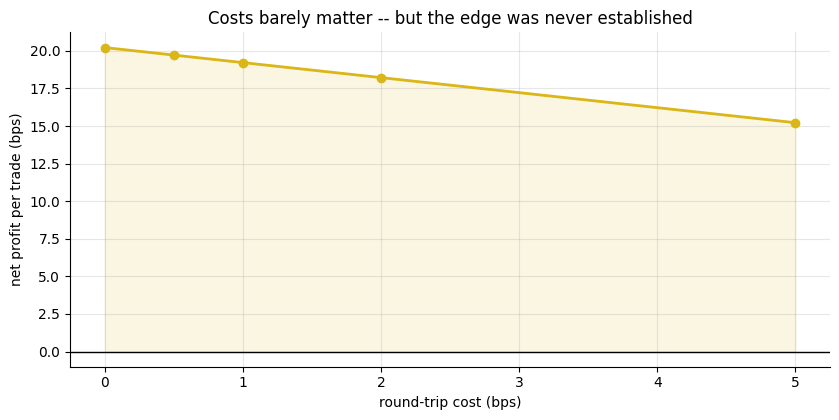

At 1bp cost: net = +19.2bps/trade -- costs not the problem


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pooled(20, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['net00'], R['net05'], R['net10'], R['net20'], R['net50']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n>0 for n in net], color=AMBER, alpha=0.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('Costs barely matter -- but the edge was never established')
plt.tight_layout(); plt.show()
print(f'At 1bp cost: net = {net[2]:+.1f}bps/trade -- costs not the problem')

Unlike the typical mirage story (positive gross but killed by costs), the Vortex crossover survives even 5 bps of cost at 20-day hold — it stays positive. The failure is purely statistical: the *t*-stat never clears 2. A signal that 'looks like it works but has t=1.6' is the quant equivalent of a paper gain that you can't withdraw: it's there on the chart, but you cannot bank it.

## 7 · Going further

- **Is it real on individual instruments?** IWM reaches *t* = +1.51 at 14 days — the best single-instrument result. Small-caps may have more exploitable trends. That's a hypothesis, not a certified edge.
- **The related indicators.** Wilder's +DI/−DI (the conceptual ancestor of Vortex) and ADX are tested in [Study 106 — Supertrend](../../106-supertrend/). The MACD crossover family is [Study 78 — Crossed-Wires](../../78-crossed-wires/).
- **The opposite bet.** If daily moves *reverse* rather than continue post-cross, the Vortex is on the wrong side. Check the sign reversal.
- **Could a longer period (21, 28 days) help?** Longer VI periods produce fewer crossovers and thus less data, but may better match the trend cycle of a given asset.

*Think the edge is real? Fork this, change the hold horizon or the instrument basket, run a White Reality Check, and show |t| > 2 that survives multiple comparisons. That is the bar.*